In [ ]:
#Analisi stagionale fonte per fonte

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

produzione = pd.read_csv('Rinnovabili_Pulito:Mesi_2021_2026.csv')
produzione

,Date,Biomass,Geothermal,Hydro,Photovoltaic,Wind
0,2021-01,1579.200,464.485,3735.671,902.158,2615.172
1,2021-02,1418.232,426.850,3590.643,1423.348,1699.267
2,2021-03,1566.634,475.560,3263.113,2319.726,1838.063
3,2021-04,1487.184,459.040,3345.190,2371.714,1554.452
4,2021-05,1474.692,465.170,4977.786,2941.709,1999.789
...,...,...,...,...,...,...
57,2025-10,1156.928,440.780,2816.993,3321.774,2319.776
58,2025-11,1163.135,433.660,2617.487,2280.879,1803.716
59,2025-12,1442.446,445.860,2156.282,1777.739,1469.436
60,2026-01,1233.227,416.310,2559.285,1651.102,2974.892


In [2]:
produzione['Mese'] = pd.to_datetime(produzione['Date']).dt.month
produzione['Mese']
produzione[['Date','Mese']].head(12)

,Date,Mese
0,2021-01,1
1,2021-02,2
2,2021-03,3
3,2021-04,4
4,2021-05,5
5,2021-06,6
6,2021-07,7
7,2021-08,8
8,2021-09,9
9,2021-10,10


In [3]:
stagionale = produzione.groupby('Mese')[['Biomass','Geothermal','Hydro','Photovoltaic','Wind']].mean()
stagionale

,Biomass,Geothermal,Hydro,Photovoltaic,Wind
Mese,,,,,
1,1331.826000,455.149167,2852.034333,1299.531167,2623.6995
2,1205.189333,413.563333,2454.150333,1824.140667,2014.6465
3,1370.173400,459.780000,2710.939000,2670.235400,2214.8470
4,1252.313800,446.524000,3086.181800,3264.633200,2024.2354
5,1274.011200,455.148000,4765.515200,3605.738000,1639.9586
6,1232.274000,434.238000,5172.559800,3917.309400,1162.6224
7,1309.648600,451.598000,4734.425800,4123.615200,1356.9714
8,1279.885000,446.338000,3947.986800,3807.585600,1355.5770
9,1241.118000,438.962000,3335.569600,3020.023200,1439.4118


In [4]:
mesi = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']

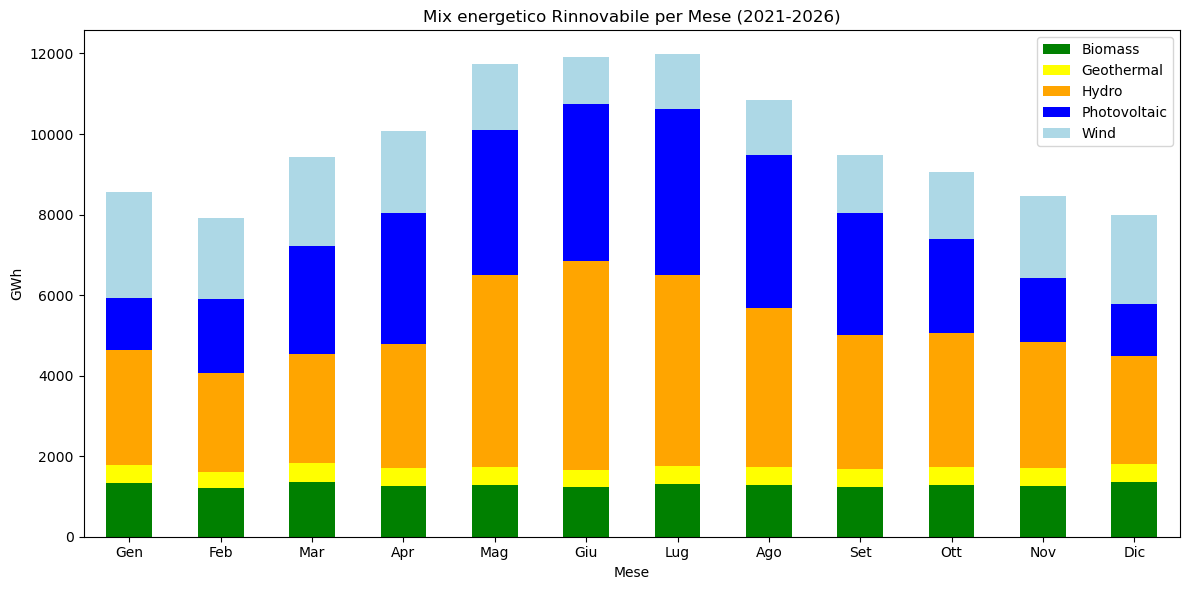

In [21]:
stagionale.plot(kind='bar', stacked=True, figsize=(12,6), color = ['green', 'yellow', 'orange', 'blue', 'lightblue'] )

plt.xticks(ticks=range(12), labels = mesi, rotation=0)
plt.title('Mix energetico Rinnovabile per Mese (2021-2026)')
plt.ylabel('GWh')
plt.xlabel('Mese')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("Mix Energetico Rinnovabile Mensile.jpeg")
plt.show()

In [15]:
#GRAFICO PIE CHART ANNUALE
media_annuale = stagionale[['Biomass','Geothermal','Hydro','Photovoltaic','Wind']].mean().round(3)
media_annuale

Biomass         1283.163
Geothermal       445.815
Hydro           3515.554
Photovoltaic    2728.971
Wind            1812.434
dtype: float64

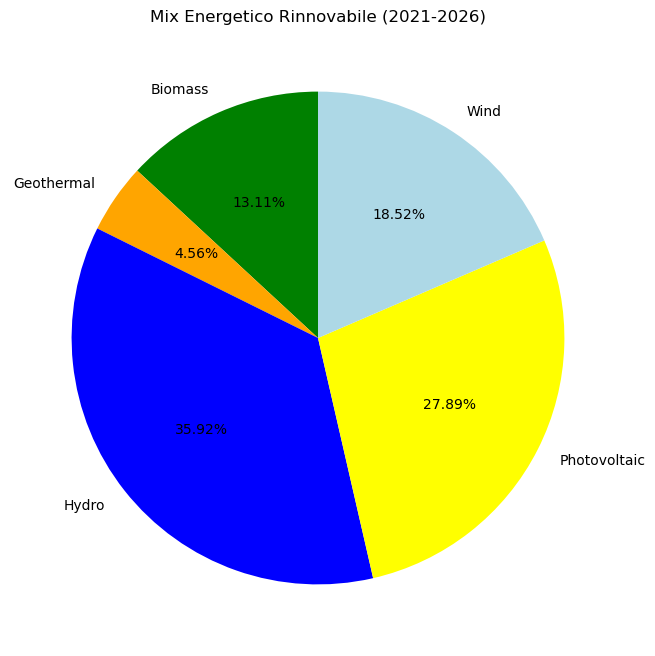

In [36]:
#PIE CHART
plt.figure(figsize=(8,8))

plt.pie(
    media_annuale, labels=media_annuale.index, autopct='%1.2f%%', colors=['green', 'orange', 'blue', 'yellow', 'lightblue'], startangle=90)
#autopct='%1.1f%%' — calcola e scrive automaticamente le percentuali dentro ogni fetta, con 1 decimale
plt.title('Mix Energetico Rinnovabile (2021-2026)')
plt.savefig("Mix Energetico Rinnovabile Pie_Chart.jpeg")
plt.show()